### Desenvolvimento

**Problema:** O transporte aéreo é uma parte vital da infraestrutura global, mas os atrasos de voos impactam milhões de passageiros todos os anos. Este projeto utiliza o conjunto de dados público que contém informações detalhadas sobre voos nos EUA para desenvolver análises e modelos preditivos e exploratórios aplicando técnicas de Machine Learning supervisionado e não supervisionado, desenvolvendo um pipeline completo de ciência de dados, desde a exploração dos dados até a interpretação dos resultados. 
Aqui entende-se o atraso de voos como o atraso para embarque, visto que o ocorrido pode gerar vários impactos para a companhia aérea, como financeiros, operacionais e até de reputação.

**Itens obrigatórios:**

1. Investigue os dados com estatísticas descritivas. 
2. Crie visualizações que trazem insights. 
3. Trate valores ausentes de forma adequada.
4. Criar variáveis derivadas (ex.: período do dia, feriados, estações do ano). 
5. Analisar atrasos por aeroporto, companhia ou estado. 
6. Criar mapas geográficos de rotas e atrasos.
7. Identificar padrões sazonais ou horários críticos.  
8. Modelagem supervisionada (mínimo um modelo)
    * Classificação: prever se um voo vai atrasar ou não. 
    OU
    * Regressão: prever quanto tempo o atraso vai durar. Compare pelo menos dois algoritmos diferentes e avalie com métricas adequadas.   
9. Modelagem não supervisionada (mínimo uma abordagem):
    * Use clusterização (ex.: agrupar rotas, aeroportos ou companhias aéreas) ou redução de dimensionalidade (ex.: PCA). 
    * Mostre os resultados em gráficos e faça a interpretação. 
    * Compartilhe as principais conclusões. 
    * Discuta as limitações dos modelos. 
    * Proponha melhorias e próximos passos


**Perguntas que podem guiar sua análise:**
* Quais aeroportos são mais críticos em relação a atrasos? 
* Que características aumentam a chance de atraso em um voo? 
* Os atrasos são mais comuns em certos dias da semana ou horários? 
* É possível agrupar aeroportos com perfis semelhantes? 
* Até que ponto conseguimos prever atrasos com base no histórico e contexto do voo?


______________

### 1. Importações

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Carregamento dos dados

#### 2.1 Carrega df_airlines


In [ ]:
#Carrega df_airlines
df_airlines = pd.read_csv("databases/airlines.csv")

#Visualiza df_airlines
df_airlines.head()

C:\Users\alice\AppData\Local\Temp\ipykernel_1248\1308158681.py:3: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv("databases/flights.csv")


#### 2.2 Carrega df_airports


In [8]:
#Carrega df_airports
df_airports = pd.read_csv("databases/airports.csv")

#Visualiza df_airports
df_airports.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


#### 2.3 Carrega df_flights

In [ ]:
#Carrega df_flights
pd.set_option('display.max_columns', None) #visualizar todas as colunas
df_flights = pd.read_csv("databases/flights.csv")

#Visualiza df_flights
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


| Coluna              | Descrição                                                                | Tipo       |
| ------------------- | ------------------------------------------------------------------------ | ---------- |
| YEAR                | Ano do voo (ex.: 2015)                                                   | Inteiro    |
| MONTH               | Mês do voo (1 a 12)                                                      | Inteiro    |
| DAY                 | Dia do mês do voo (1 a 31)                                               | Inteiro    |
| DAY_OF_WEEK         | Dia da semana (1 = Segunda, 7 = Domingo)                                 | Inteiro    |
| AIRLINE             | Código da companhia aérea (ex.: AA = American Airlines)                  | Categórica |
| FLIGHT_NUMBER       | Número do voo                                                            | Inteiro    |
| TAIL_NUMBER         | Número de registro da aeronave                                           | Texto      |
| ORIGIN_AIRPORT      | Código IATA do aeroporto de origem (ex.: ATL)                            | Categórica |
| DESTINATION_AIRPORT | Código IATA do aeroporto de destino                                      | Categórica |
| SCHEDULED_DEPARTURE | Horário de partida programado (HHMM)                                     | Inteiro    |
| DEPARTURE_TIME      | Horário real de partida (HHMM)                                           | Inteiro    |
| DEPARTURE_DELAY     | Atraso na partida (em minutos)                                           | Numérico   |
| TAXI_OUT            | Tempo gasto taxiando até a decolagem (em minutos)                        | Numérico   |
| WHEELS_OFF          | Horário em que o avião decolou (HHMM)                                    | Inteiro    |
| SCHEDULED_TIME      | Tempo total programado de voo (em minutos)                               | Numérico   |
| ELAPSED_TIME        | Tempo total real de voo (em minutos)                                     | Numérico   |
| AIR_TIME            | Tempo no ar (em minutos)                                                 | Numérico   |
| DISTANCE            | Distância entre origem e destino (em milhas)                             | Numérico   |
| WHEELS_ON           | Horário em que as rodas tocaram o solo (HHMM)                            | Inteiro    |
| TAXI_IN             | Tempo taxiando até o portão de desembarque (em minutos)                  | Numérico   |
| SCHEDULED_ARRIVAL   | Horário de chegada programado (HHMM)                                     | Inteiro    |
| ARRIVAL_TIME        | Horário de chegada real (HHMM)                                           | Inteiro    |
| ARRIVAL_DELAY       | Atraso na chegada (em minutos)                                           | Numérico   |
| DIVERTED            | Indica se o voo foi desviado (1 = sim, 0 = não)                          | Binária    |
| CANCELLED           | Indica se o voo foi cancelado (1 = sim, 0 = não)                         | Binária    |
| CANCELLATION_REASON | Motivo do cancelamento (A = Airline, B = Weather, C = NAS, D = Security) | Categórica |
| AIR_SYSTEM_DELAY    | Atraso causado por controle de tráfego aéreo                             | Numérico   |
| SECURITY_DELAY      | Atraso causado por problemas de segurança                                | Numérico   |
| AIRLINE_DELAY       | Atraso causado pela companhia aérea                                      | Numérico   |
| LATE_AIRCRAFT_DELAY | Atraso causado por chegada tardia da aeronave                            | Numérico   |
| WEATHER_DELAY       | Atraso causado por condições meteorológicas                              | Numérico   |


#### 2.4 Base final com informações entre as três fontes origens cruzadas


In [9]:
#Cruza origens
df = pd.merge(df_flights, df_airports, left_on="ORIGIN_AIRPORT",right_on="IATA_CODE", how="left")
df = pd.merge(df, df_airlines, left_on="AIRLINE",right_on="IATA_CODE", how="left")

#apaga colunas duplicadas por conta do join e renomeia colunas 
df = df.drop(columns=["IATA_CODE_y","IATA_CODE_x"])
df = df.rename(columns={
    "AIRLINE_y": "AIRLINE_NAME",
    "AIRLINE_x": "AIRLINE_CODE"
})
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,WEATHER_DELAY,IATA_CODE_x,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE,IATA_CODE_y,AIRLINE_y
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,NaN,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,AS,Alaska Airlines Inc.
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,NaN,LAX,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,AA,American Airlines Inc.
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,NaN,SFO,San Francisco International Airport,San Francisco,CA,USA,37.61900,-122.37484,US,US Airways Inc.
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,NaN,LAX,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,AA,American Airlines Inc.
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,NaN,SEA,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,AS,Alaska Airlines Inc.


### 3. Preparação dos dados

#### 3.1 Tratamento de vazamento de informações:

Para evitar data leakage (usar informações que só existem depois do voo acontecer, que podem vazar informações sobre se houve atraso ou não), devemos remover as variaveis que não estariam disponíveis no momento em que queremos fazer a previsão, ou seja, antes do voo atrasar de fato.

In [38]:
remove_data_leakage = [
    "ARRIVAL_TIME", #só existe depois que o atraso já ocorreu
    "AIR_SYSTEM_DELAY", #motivo só existe depois que o atraso já ocorreu
    "SECURITY_DELAY", #motivo só existe depois que o atraso já ocorreu
    "AIRLINE_DELAY", #motivo só existe depois que o atraso já ocorreu
    "LATE_AIRCRAFT_DELAY", #motivo só existe depois que o atraso já ocorreu
    "WEATHER_DELAY", #motivo só existe depois que o atraso já ocorreu
    "CANCELLATION_REASON", #se o voo foi cancelado, não houve atraso 
    "WHEELS_ON", #indica que o voo já terminou e já se sabe seu tempo de duração - queremos prever o atraso com antecedência 
    "AIR_TIME", #para saber quanto tempo o avião ficou no ar, é necessário saber a hora do pouso e calcular a diferença (Se o modelo souber que o voo demorou muito no ar, ele já tem forte pista sobre o atraso)
    "ELAPSED_TIME", #o valor só é conhecido depois que o voo terminou
    "TAXI_IN" #só acontece no final do voo, então já se sabe o atraso final 
]

df_tratado = df.drop(columns=remove_data_leakage)

#### 3.2 Filtro de voos com potencial de agregar informações de fato:

Removemos os voos cancelados, pois, por não terem sido iniciados, não fornecem informações úteis sobre o desempenho dos voos para identificarmos padrões de atraso. Além disso, o filtro ajuda a reduzir o tamanho da base de dados.

In [39]:
df_tratado = df_tratado[df_tratado["CANCELLED"] == 0]

#### 3.3 Engenharia de feature: criação de novas colunas

3.3.1 Criação da coluna 'rota"


In [41]:
#df_tratado['ROUTE'] = df_tratado['ORIGIN_AIRPORT'].astype(str) + " - " + df_tratado['DESTINATION_AIRPORT'].astype(str)
#df_tratado[['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
0,ANC,SEA,ANC - SEA
1,LAX,PBI,LAX - PBI
2,SFO,CLT,SFO - CLT
3,LAX,MIA,LAX - MIA
4,SEA,ANC,SEA - ANC


3.3.2 Criação da coluna 'período do dia"


In [42]:
def periodo_do_dia(horario):
    """
    Recebe o horário no formato HHMM (ex: 5 -> 00:05, 1330 -> 13:30)
    e retorna o período do dia: 'Madrugada', 'Manhã', 'Tarde', 'Noite'
    """
    if pd.isnull(horario):
        return None
    # transformar HHMM em hora inteira
    hora = int(horario) // 100

    if 0 <= hora < 6:
        return "Madrugada"
    elif 6 <= hora < 12:
        return "Manhã"
    elif 12 <= hora < 18:
        return "Tarde"
    else:
        return "Noite"


df_tratado['PERIODO_DO_DIA'] = df_tratado['SCHEDULED_DEPARTURE'].apply(periodo_do_dia)

3.3.3 Mantém os nomes completos das 10 origens, destinos e companhias mais frequentes e agrupa os demais em 'Other', reduzindo o número de variáveis e evitando sobrecarga no processamento durante a etapa de one-hot encoding, obtendo categorias reduzidas que cabem na memória.

In [28]:
# Top 10 aeroportos de origem
top_orig = df_tratado['ORIGIN_AIRPORT'].value_counts().nlargest(10).index
df_tratado['ORIGIN_AIRPORT_TOP'] = df_tratado['ORIGIN_AIRPORT'].apply(lambda x: x if x in top_orig else 'Other')

# Top 10 aeroportos de destino
top_dest = df_tratado['DESTINATION_AIRPORT'].value_counts().nlargest(10).index
df_tratado['DESTINATION_AIRPORT_TOP'] = df_tratado['DESTINATION_AIRPORT'].apply(lambda x: x if x in top_dest else 'Other')

# Top 10 companhias aéreas
top_airlines = df_tratado['AIRLINE_CODE'].value_counts().nlargest(10).index
df_tratado['AIRLINE_TOP'] = df_tratado['AIRLINE_CODE'].apply(lambda x: x if x in top_airlines else 'Other')

#remove as colunas originais do dataframe
remove_colunas_originais = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT","AIRLINE_CODE" ]   
df_tratado = df_tratado.drop(columns=remove_colunas_originais)

#### 3.3 Análise da distribuição dos dados 

In [17]:
df_tratado.shape

(5729195, 27)

O dataset tem cerca de 5,8 milhões de voos.

In [16]:
df_tratado[["SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "DEPARTURE_DELAY", "TAXI_OUT", "WHEELS_OFF", "SCHEDULED_TIME", "DISTANCE", "SCHEDULED_ARRIVAL", "DIVERTED"]].describe()

,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,DIVERTED
count,5.729195e+06,5.729195e+06,5.729195e+06,5.729195e+06,5.729195e+06,5.729194e+06,5.729195e+06,5.729195e+06,5.729195e+06
mean,1.328890e+03,1.335102e+03,9.338837e+00,1.607112e+01,1.357142e+03,1.419480e+02,8.248575e+02,1.493315e+03,2.650809e-03
std,4.834692e+02,4.963902e+02,3.699246e+01,8.894483e+00,4.979969e+02,7.533501e+01,6.087992e+02,5.068360e+02,5.141772e-02
min,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,3.100000e+01,1.000000e+00,0.000000e+00
25%,9.160000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.600000e+01,3.730000e+02,1.110000e+03,0.000000e+00
50%,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,6.500000e+02,1.520000e+03,0.000000e+00
75%,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.740000e+02,1.066000e+03,1.917000e+03,0.000000e+00
max,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,4.983000e+03,2.400000e+03,1.000000e+00


Visualizações

In [26]:
# Selecionar as variáveis numéricas que você mencionou + target
cols = [
    "SCHEDULED_DEPARTURE", 
    "DEPARTURE_TIME", 
    "DEPARTURE_DELAY",
    "TAXI_OUT", 
    "WHEELS_OFF", 
    "SCHEDULED_TIME", 
    "DISTANCE",
    "SCHEDULED_ARRIVAL", 
    "DIVERTED", 
    "ARRIVAL_DELAY", 
    "ROUTE",
    "PERIODO_DO_DIA",
    "DAY_OF_WEEK",
    "AIRLINE_CODE",
    "TAIL_NUMBER",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "AIRPORT",
    "CITY",
    "STATE",
    "COUNTRY"
]

# Criar um dataframe apenas com essas colunas
df_corr = df_tratado[cols]

corr_matrix = df_corr.corr()

ValueError: could not convert string to float: 'ANC - SEA'

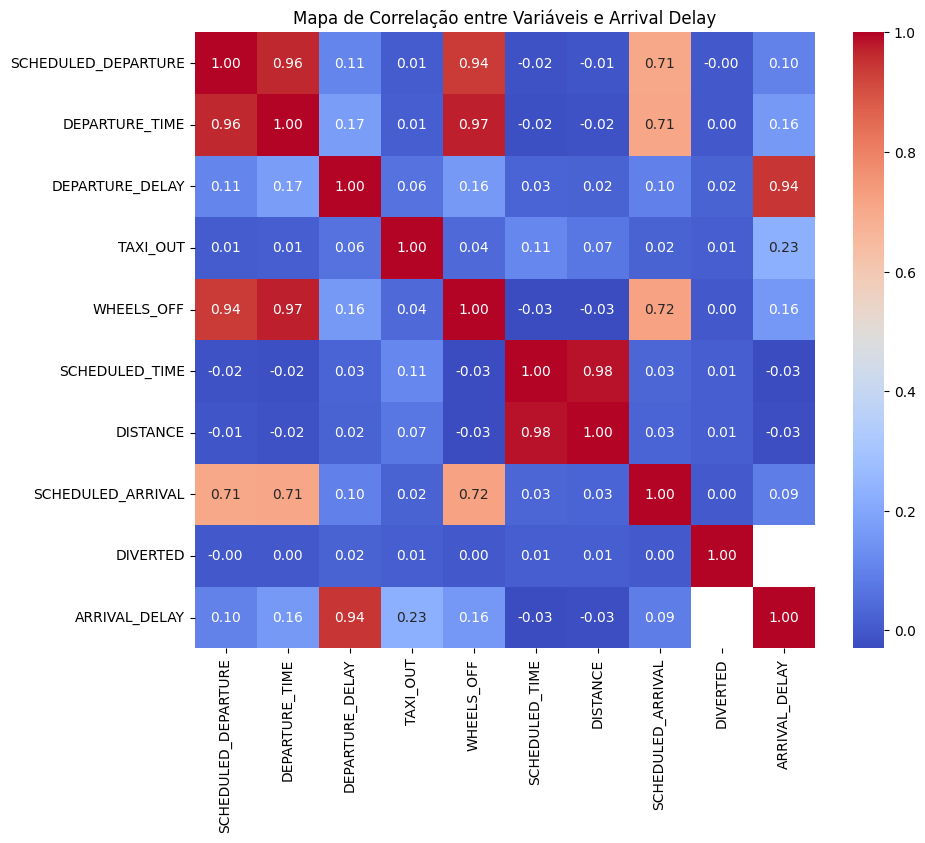

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de Correlação entre Variáveis e Arrival Delay")
plt.show()

1. Voos de algum período (manha/tarde/noite) atrasam mais?
2. Atraso na partida está diretamente ligado com atraso na chegada?
3. Voos mais longos atrasam mais?
4. Companhias aéreas específicas atrasam mais?
5. Existe uma rota que atrasa mais?
6. Existe um aeroporto que atras mais?
7. Existe sazonalidade? 
8. Os dados estão balanceados? ou existe mais registro de aeroportos/regioes específicas?

In [28]:
df.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE_CODE                 0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRPORT                 486165
CITY    